In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
def makehist(df,col,title=""): # A func to help make (making histograms) easier
  sns.histplot(data = df, x = df[col],kde=True)
  plt.title(title)
  plt.show()
std_scaler = StandardScaler() #Assigning the standard scaler, to use later
df = pd.read_csv("/content/AmesHousingCleaned.csv")

In [2]:
#TASK1
df = pd.get_dummies(df, columns=["Neighborhood", "Sale Condition"]) # One-hot encodes these two cols
df.head() # prints the first 5 cols


,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Sale Condition_Abnorml,Sale Condition_AdjLand,Sale Condition_Alloca,Sale Condition_Family,Sale Condition_Normal,Sale Condition_Partial
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,False,False,False,False,False,False,False,False,True,False
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,False,False,False,False,False,False,False,False,True,False
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,False,False,False,False,False,False,False,False,True,False
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,False,False,False,False,False,False,False,False,True,False
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,False,False,False,False,False,False,False,False,True,False


In [3]:
#TASK2
O_Q=pd.CategoricalDtype(
    categories=["Fa","TA","Gd","EX"], ordered=True) # FA(Fair) = 0, TA(Typical/Average) = 1, Gd(Good) = 2, EX(Excellent) = 3
df["Exter Qual_O_E"] = df["Exter Qual"].astype(O_Q).cat.codes # ordinal codes this col
print(df["Exter Qual"])

0       TA
1       TA
2       TA
3       Gd
4       TA
        ..
2925    TA
2926    TA
2927    TA
2928    TA
2929    TA
Name: Exter Qual, Length: 2930, dtype: object


In [4]:
#TASK3
df[["LotAreaScaled", "Total Bsmt SF_Scaled"]] = std_scaler.fit_transform(df[["Lot Area", "Total Bsmt SF"]]) #uses standard scaler on these cols, so the mean becomes 0 and the std becomes 1

In [5]:
#TASK4
#1 Price per square feet
df["Price_per_SF"] = df["SalePrice"] / df["Lot Area"]
for i in df["Price_per_SF"]:
  print(f"The price of 1 SF is: {i}")
#2 Total num of bathrooms
df["TNumOfBathrooms"] =  df["Bsmt Full Bath"] + df["Bsmt Half Bath"] + df["Full Bath"]+ df["Half Bath"]
print(df["TNumOfBathrooms"])

The price of 1 SF is: 6.767390620081838
The price of 1 SF is: 9.034589571502323
The price of 1 SF is: 12.05579308894652
The price of 1 SF is: 21.863799283154123
The price of 1 SF is: 13.731019522776572
The price of 1 SF is: 19.59310483062738
The price of 1 SF is: 43.39430894308943
The price of 1 SF is: 38.26173826173826
The price of 1 SF is: 43.885693078493226
The price of 1 SF is: 25.2
The price of 1 SF is: 17.59
The price of 1 SF is: 23.182957393483708
The price of 1 SF is: 21.47107831468698
The price of 1 SF is: 16.853380503144653
The price of 1 SF is: 31.085043988269796
The price of 1 SF is: 10.055322966507177
The price of 1 SF is: 13.515740893357508
The price of 1 SF is: 34.617517991925574
The price of 1 SF is: 7.367541017870206
The price of 1 SF is: 15.939278937381404
The price of 1 SF is: 16.168836694749384
The price of 1 SF is: 16.0
The price of 1 SF is: 28.8
The price of 1 SF is: 13.255048483231029
The price of 1 SF is: 11.9566084390205
The price of 1 SF is: 16.80473372781065


In [6]:
#TASK5
df["Qual X Price"] = df["Overall Qual"] * df["SalePrice"] #An interactive feature

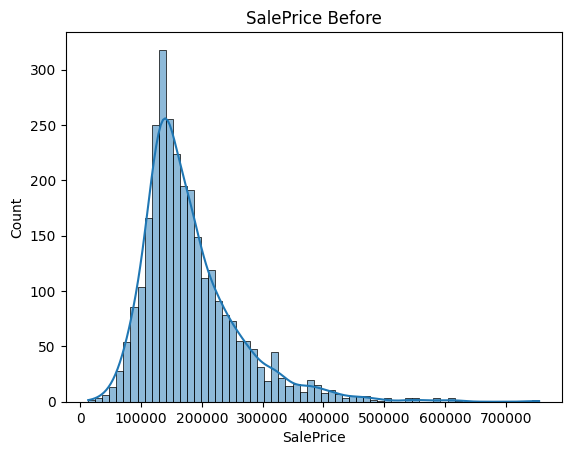

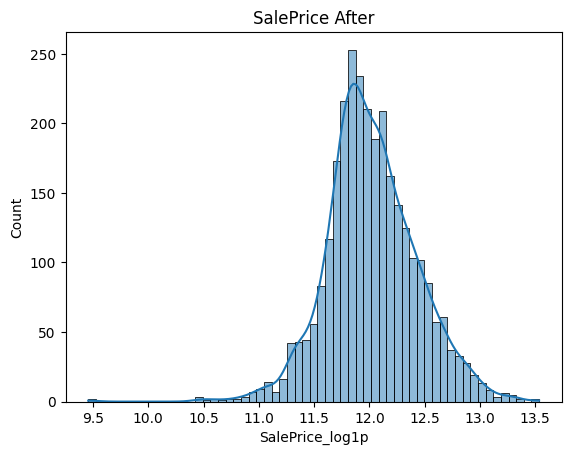

In [7]:
#TASK6
makehist(df,"SalePrice","SalePrice Before") #Showing the data before transforming
df["SalePrice_log1p"] = np.log1p(df["SalePrice"]) # Transforming the col
makehist(df,"SalePrice_log1p", "SalePrice After") #Showing the data after transforming

In [8]:
#TASK7
bin_edges = [1872, 1901, 1921, 1941, 1961, 1981, 2001, 2011]
labels = ["1872-1900","1901-1920","1921-1940","1941-1960","1961-1980","1981-2000","2001-2010"]
df["YR Built Bins"] = pd.cut(df["Year Built"], bins =bin_edges,labels=labels,right=False) # this cuts the data into Bins(groups)

In [9]:
#TASK8
corr_matrix = df[[
"Lot Area",
"Yr Sold",
"Mo Sold",
"MS SubClass",
"Lot Frontage",
"Overall Qual",
"Overall Cond",
"Year Built",
"Year Remod/Add",
"Mas Vnr Area",
"BsmtFin SF 1",
"BsmtFin SF 2",
"Bsmt Unf SF",
"Total Bsmt SF",
"1st Flr SF",
"2nd Flr SF",
"Low Qual Fin SF",
"Gr Liv Area",
"Bsmt Full Bath",
"Bsmt Half Bath",
"Full Bath",
"Half Bath",
"Bedroom AbvGr",
"Kitchen AbvGr",
"TotRms AbvGrd",
"Fireplaces",
"Garage Yr Blt",
"Garage Cars",
"Garage Area",
"Wood Deck SF",
"Open Porch SF",
"Enclosed Porch",
"3Ssn Porch",
"Screen Porch",
"Pool Area",
"Misc Val","SalePrice"]].corr()


for cols in corr_matrix.columns: # Iterates in cols
     for rows in corr_matrix.index: # Iterates in rows
      if corr_matrix.loc[rows, cols] >= 0.95: # Gets the data via the ["Row", "Col"]
        if cols != rows: # I used this because always when the col is the same as the row, the correlation will be 1
          print(cols, "   ", rows, " - > ", corr_matrix.loc[rows, cols] ) # if it isn't the same, print it (There isn't any)